In [ ]:
!pip install tenseal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 39.7 MB/s eta 0:00:00


In [ ]:
from google.colab import files
import json
import numpy as np
import tenseal as ts

# Upload the JSON file (This is still done on the server)
uploaded = files.upload()
filename = list(uploaded.keys())[0]

with open(filename, "r") as f:
    data = json.load(f)

Saving MMU (1).json to MMU (1).json


In [ ]:
# First, let's inspect what users we actually have in the original data
print("Users in original data:", list(data.keys())[:10])  # Show first 10 user IDs
print("Total users in data:", len(data))

# Check if user '1' exists in the original data
if '1' not in data:
    print("WARNING: User '1' does not exist in the original data!")
    # Let's use the first available user instead
    first_user_id = list(data.keys())[0]
    print(f"Using first available user: {first_user_id}")
else:
    first_user_id = '1'

Users in original data: ['1', '2', '3', '5', '6', '7', '8', '9', '10', '11']
Total users in data: 43


In [ ]:
# Secure storage for private keys
user_private_keys = {}

# Database to store encrypted data
encrypted_database = {}

print("\n=== BUILDING ENCRYPTED DATABASE WITH NORMALIZATION ===")


def normalize_vector(v):
    import numpy as np
    v = np.array(v, dtype=np.float64)
    norm = np.linalg.norm(v)
    return (v / norm).tolist() if norm > 0 else v.tolist()

for user_id, user_data in data.items():
    print(f"Processing User {user_id}...")

    try:
        # Generate encryption context
        user_context = ts.context(
            ts.SCHEME_TYPE.CKKS,
            poly_modulus_degree=8192,
            coeff_mod_bit_sizes=[60, 40, 40, 60]
        )
        user_context.generate_galois_keys()
        user_context.global_scale = 2 ** 40

        # Store private key
        user_private_key = user_context.serialize(save_secret_key=True)
        user_private_keys[user_id] = user_private_key
        print(f"  ✓ Private key stored for user {user_id}")

        # Create public context
        user_public_context = user_context.copy()
        user_public_context.make_context_public()

        # ============================================
        # NORMALIZE EACH VECTOR BEFORE ENCRYPTION
        # ============================================
        user_encrypted_features = []
        for vec in user_data["features"]:
            # THIS IS THE KEY LINE - NORMALIZE FIRST!
            normalized_vec = normalize_vector(vec)

            # Encrypt the normalized vector
            enc_vec = ts.ckks_vector(user_public_context, normalized_vec)
            user_encrypted_features.append(enc_vec.serialize())

        # Store in database
        user_public_key = user_public_context.serialize()
        encrypted_database[user_id] = {
            'public_key': user_public_key,
            'encrypted_features': user_encrypted_features
        }

        print(f"  ✓ Added User {user_id} to database with {len(user_encrypted_features)} NORMALIZED features")

    except Exception as e:
        print(f"  ✗ Error with User {user_id}: {e}")
        continue

print(f"✓ Enrollment completed. Stored private keys for {len(user_private_keys)} users")


=== BUILDING ENCRYPTED DATABASE WITH NORMALIZATION ===
Processing User 1...
  ✓ Private key stored for user 1
  ✓ Added User 1 to database with 10 NORMALIZED features
Processing User 2...
  ✓ Private key stored for user 2
  ✓ Added User 2 to database with 10 NORMALIZED features
Processing User 3...
  ✓ Private key stored for user 3
  ✓ Added User 3 to database with 10 NORMALIZED features
Processing User 5...
  ✓ Private key stored for user 5
  ✓ Added User 5 to database with 10 NORMALIZED features
Processing User 6...
  ✓ Private key stored for user 6
  ✓ Added User 6 to database with 10 NORMALIZED features
Processing User 7...
  ✓ Private key stored for user 7
  ✓ Added User 7 to database with 10 NORMALIZED features
Processing User 8...
  ✓ Private key stored for user 8
  ✓ Added User 8 to database with 10 NORMALIZED features
Processing User 9...
  ✓ Private key stored for user 9
  ✓ Added User 9 to database with 10 NORMALIZED features
Processing User 10...
  ✓ Private key stored for

In [ ]:
# Verify the database was built correctly
print("\n=== DATABASE VERIFICATION ===")
print("Users in encrypted database:", sorted(list(encrypted_database.keys()))[:10])
print(f"Total users in encrypted database: {len(encrypted_database)}")

# Check if specific users exist
for user_id in ['1', '2', '3', '44']:
    if user_id in encrypted_database:
        print(f"✓ User {user_id} found in database")
    else:
        print(f"✗ User {user_id} NOT found in database")


=== DATABASE VERIFICATION ===
Users in encrypted database: ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18']
Total users in encrypted database: 43
✓ User 1 found in database
✓ User 2 found in database
✓ User 3 found in database
✓ User 44 found in database


In [ ]:
def cosine_similarity_encrypted_public(v1, v2):
    """
    Compute cosine similarity using only homomorphic operations.
    Returns encrypted similarity score.
    """
    # Encrypted dot product
    dot_product = v1.dot(v2)

    # Encrypted squared norms
    norm_sq_v1 = v1.dot(v1)
    norm_sq_v2 = v2.dot(v2)

    # We can't decrypt the norms on server, so we return the encrypted components
    # Client will decrypt and compute final similarity
    return dot_product, norm_sq_v1, norm_sq_v2

In [ ]:

class AuthenticationXAI:
    def __init__(self, threshold=0.70):
        self.threshold = threshold

    def explain_authentication(self, query_user_id, template_scores, feature_similarities_all, threshold=0.70):
        """
        Generate human-readable explanations for authentication decisions.
        """

        print(f"\n{'='*60}")
        print("EXPLAINABLE AI (XAI) - AUTHENTICATION DECISION ANALYSIS")
        print(f"{'='*60}")

        if not template_scores:
            print("ERROR: No template scores available for analysis")
            return

        best_template_idx = np.argmax(template_scores)
        best_score = template_scores[best_template_idx]

        is_authenticated = best_score >= threshold

        print(f"\n🔍 USER ANALYSIS: {query_user_id}")
        print(f"📊 BEST MATCH SCORE: {best_score:.4f}")
        print(f"🎯 THRESHOLD: {threshold}")
        print(f"📋 AUTHENTICATION: {'SUCCESSFUL ✅' if is_authenticated else 'FAILED ❌'}")
        print(f"📈 MARGIN: {best_score - threshold:+.4f}")

        # Overall score analysis
        print(f"\n📊 OVERALL SCORE ANALYSIS:")
        print(f"   • Templates analyzed: {len(template_scores)}")
        print(f"   • Templates above threshold: {sum(1 for s in template_scores if s >= threshold)}")
        print(f"   • Average template score: {np.mean(template_scores):.4f}")
        print(f"   • Score variance: {np.var(template_scores):.4f}")

        if len(template_scores) > 1:
            sorted_scores = sorted(template_scores, reverse=True)
            if sorted_scores[0] - sorted_scores[1] > 0.1:
                print(f"   • Best template significantly outperforms others")
            elif sorted_scores[0] - sorted_scores[1] < 0.05:
                print(f"   • Multiple templates show similar performance")

        # Feature-level analysis if available
        if feature_similarities_all and len(feature_similarities_all) > best_template_idx:
            feature_scores = feature_similarities_all[best_template_idx]
            if feature_scores:
                print(f"\n📈 FEATURE-LEVEL ANALYSIS (Best Template {best_template_idx + 1}):")

                for i, score in enumerate(feature_scores):
                    status = "✓" if score >= 0.7 else ("∼" if score >= 0.5 else "✗")
                    contribution = "HIGH" if score >= 0.8 else ("MEDIUM" if score >= 0.6 else "LOW")
                    print(f"   Feature {i+1}: {status} {score:.4f} ({contribution})")

                # Identify strongest and weakest features
                if len(feature_scores) > 1:
                    best_feature = np.argmax(feature_scores)
                    worst_feature = np.argmin(feature_scores)

                    if feature_scores[best_feature] >= 0.8:
                        print(f"   → Feature {best_feature + 1} was strongest contributor")
                    if feature_scores[worst_feature] < 0.5:
                        print(f"   → Feature {worst_feature + 1} was weakest contributor")

        # Decision explanation
        print(f"\n🎯 DECISION EXPLANATION:")
        if is_authenticated:
            print(f"   1. Template {best_template_idx + 1} achieved {best_score*100:.1f}% similarity")
            print(f"   2. Exceeded threshold by {(best_score - threshold)*100:.1f}%")

            if best_score >= 0.85:
                print(f"   3. Very strong biometric match detected")
            elif best_score >= 0.75:
                print(f"   3. Strong biometric match confirmed")
            else:
                print(f"   3. Adequate biometric match established")

            # Check consistency
            high_scoring_templates = sum(1 for s in template_scores if s >= threshold)
            if high_scoring_templates >= 3:
                print(f"   4. Multiple templates ({high_scoring_templates}) support authentication")

        else:
            print(f"   1. Best template only achieved {best_score*100:.1f}% similarity")
            print(f"   2. Fell short of threshold by {(threshold - best_score)*100:.1f}%")

            if best_score >= 0.65:
                print(f"   3. Close match but below security threshold")
                print(f"   4. Consider using more features or adjusting threshold slightly")
            elif best_score >= 0.5:
                print(f"   3. Moderate match - possible biometric variation")
                print(f"   4. Recommend re-capturing biometric data")
            else:
                print(f"   3. Poor match - likely incorrect user or data issue")
                print(f"   4. Consider re-enrollment")

        # Confidence assessment
        print(f"\n💡 CONFIDENCE ASSESSMENT:")
        if best_score >= 0.85:
            confidence = "VERY HIGH"
        elif best_score >= 0.75:
            confidence = "HIGH"
        elif best_score >= threshold:
            confidence = "MODERATE"
        elif best_score >= 0.6:
            confidence = "LOW"
        else:
            confidence = "VERY LOW"

        print(f"   • Decision Confidence: {confidence}")

        if is_authenticated:
            if confidence in ["VERY HIGH", "HIGH"]:
                print(f"   • Recommended Action: Grant full access")
            else:
                print(f"   • Recommended Action: Grant limited access + additional verification")
        else:
            if best_score >= 0.65:
                print(f"   • Recommended Action: Request re-authentication with more features")
            else:
                print(f"   • Recommended Action: Deny access + security alert")

        print(f"\n{'='*60}")
        print("XAI ANALYSIS COMPLETE")
        print(f"{'='*60}")

In [ ]:
query_user_id = '24'

print(f"\n=== AUTHENTICATING USER {query_user_id} ===")

if query_user_id not in encrypted_database:
    print(f"ERROR: User {query_user_id} not found!")
    exit()

# ============================================
# FIX 1: ADD NORMALIZATION FUNCTION
# ============================================
def normalize_vector(v):
    """Normalize vector to unit length for cosine similarity"""
    import numpy as np
    v = np.array(v, dtype=np.float64)
    norm = np.linalg.norm(v)
    if norm > 0:
        return v / norm
    return v

# ============================================
# FIX 2: GET QUERY FEATURES AND NORMALIZE THEM
# ============================================

# Get query vectors from dataset (THESE ARE RAW, NEED NORMALIZATION!)
query_features = [
    [-403.691303565368, -198.4814013615891, 77.55259193171345, -37.471253039648545, 35.11382073237985],
    [-370.80670640425615, -215.53142283509877, 69.66043410086661, -22.568455230436133, -20.088267124066007]
]

print(f"✓ Selected {len(query_features)} query features: Feature 5 and Feature 6")

normalized_queries = []
for i, feat in enumerate(query_features):
    normalized = normalize_vector(feat)
    normalized_queries.append(normalized)

    # Print norms for debugging
    original_norm = np.linalg.norm(feat)
    normalized_norm = np.linalg.norm(normalized)
    print(f"  Feature {i+1}: original norm = {original_norm:.2f}, normalized norm = {normalized_norm:.2f}")

print("✓ All query features normalized to unit length")

# ============================================
# STEP 1: Retrieve the target user's public context
# ============================================
target_data = encrypted_database[query_user_id]
target_public_context = ts.context_from(target_data['public_key'])

# ============================================
# STEP 2: Encrypt NORMALIZED query vectors
# ============================================
enc_queries = []
for i, query_vec in enumerate(normalized_queries):
    # Convert numpy array to list for encryption
    enc_query = ts.ckks_vector(target_public_context, query_vec.tolist())
    enc_queries.append(enc_query)
print(f"✓ {len(enc_queries)} normalized query features encrypted with correct public key")

# ============================================
# STEP 3: Retrieve private context
# ============================================
try:
    if query_user_id not in user_private_keys:
        print(f"✗ No private key found for user {query_user_id}")
        print("  Make sure enrollment was run with proper key storage")
        exit()

    user_private_context = ts.context_from(user_private_keys[query_user_id])
    print("✓ Retrieved private context with secret key")

except Exception as e:
    print(f"✗ Failed to retrieve private context: {e}")
    exit()


=== AUTHENTICATING USER 24 ===
✓ Selected 2 query features: Feature 5 and Feature 6
  Feature 1: original norm = 459.36, normalized norm = 1.00
  Feature 2: original norm = 435.56, normalized norm = 1.00
✓ All query features normalized to unit length
✓ 2 normalized query features encrypted with correct public key
✓ Retrieved private context with secret key


In [ ]:
print(f"\n=== SERVER-SIDE COMPARISON (Processing {len(enc_queries)} features) ===")

target_data = encrypted_database[query_user_id]
target_public_context = ts.context_from(target_data['public_key'])
target_enc_features = target_data['encrypted_features']

# Store all encrypted results for each feature and each template
encrypted_results_all = []  # This will be a 2D list: [template_index][feature_index]

for template_idx, enc_feat_serialized in enumerate(target_enc_features):
    try:
        # Deserialize encrypted template vector with public context
        enc_feat = ts.ckks_vector_from(target_public_context, enc_feat_serialized)

        template_results = []

        # Compare each query feature with this template
        for feature_idx, enc_query in enumerate(enc_queries):
            # Compute encrypted similarity (dot product, norm squared) for each feature
            dot_product, norm_sq_v1, norm_sq_v2 = cosine_similarity_encrypted_public(enc_query, enc_feat)

            # Store encrypted results for this feature
            template_results.append({
                'dot_product': dot_product.serialize(),
                'norm_sq_v1': norm_sq_v1.serialize(),
                'norm_sq_v2': norm_sq_v2.serialize()
            })

        # Add all feature results for this template
        encrypted_results_all.append(template_results)
        print(f"  ✓ Template {template_idx + 1}: All {len(enc_queries)} feature comparisons completed")

    except Exception as e:
        print(f"  ✗ Template {template_idx + 1}: Error during comparison: {e}")
        encrypted_results_all.append([])  # Empty list for failed template



decrypted_average_scores = []
successful_decryptions = 0

for template_idx, template_results in enumerate(encrypted_results_all):
    if not template_results:  # Skip failed comparisons
        print(f"  ✗ Template {template_idx + 1}: Skipping - no comparison results")
        decrypted_average_scores.append(0.0)
        continue

    try:
        feature_similarities = []

        # Decrypt and compute similarity for each feature
        for feature_idx, result in enumerate(template_results):
            # Deserialize encrypted vectors with private context (secret key)
            dot_product_enc = ts.ckks_vector_from(user_private_context, result['dot_product'])
            norm_sq_v1_enc = ts.ckks_vector_from(user_private_context, result['norm_sq_v1'])
            norm_sq_v2_enc = ts.ckks_vector_from(user_private_context, result['norm_sq_v2'])

            # Decrypt the components
            dot_product = dot_product_enc.decrypt()[0]
            norm_sq_v1_val = norm_sq_v1_enc.decrypt()[0]
            norm_sq_v2_val = norm_sq_v2_enc.decrypt()[0]

            # Calculate cosine similarity safely
            norm_sq_v1_val = max(0, norm_sq_v1_val)
            norm_sq_v2_val = max(0, norm_sq_v2_val)
            norm_v1 = np.sqrt(norm_sq_v1_val) if norm_sq_v1_val > 0 else 0
            norm_v2 = np.sqrt(norm_sq_v2_val) if norm_sq_v2_val > 0 else 0

            if norm_v1 == 0 or norm_v2 == 0:
                similarity = 0.0
            else:
                similarity = dot_product / (norm_v1 * norm_v2)

            similarity = max(-1.0, min(1.0, similarity))
            feature_similarities.append(similarity)

        # Calculate average similarity across all features for this template
        average_similarity = sum(feature_similarities) / len(feature_similarities)
        decrypted_average_scores.append(average_similarity)
        successful_decryptions += 1

    except Exception as e:
        print(f"  ✗ Template {template_idx + 1}: Error decrypting: {e}")
        decrypted_average_scores.append(0.0)


=== SERVER-SIDE COMPARISON (Processing 2 features) ===
  ✓ Template 1: All 2 feature comparisons completed
  ✓ Template 2: All 2 feature comparisons completed
  ✓ Template 3: All 2 feature comparisons completed
  ✓ Template 4: All 2 feature comparisons completed
  ✓ Template 5: All 2 feature comparisons completed
  ✓ Template 6: All 2 feature comparisons completed
  ✓ Template 7: All 2 feature comparisons completed
  ✓ Template 8: All 2 feature comparisons completed
  ✓ Template 9: All 2 feature comparisons completed
  ✓ Template 10: All 2 feature comparisons completed


In [ ]:
# Cell 10: Client-side Decryption with XAI Data Collection
print(f"\n=== CLIENT-SIDE DECRYPTION AND AVERAGE COMPUTATION ===")

decrypted_average_scores = []
feature_similarities_all = []  # NEW: Store feature-level scores for XAI
successful_decryptions = 0

# NEW: Track templates that meet the feature threshold
templates_meeting_threshold = 0
threshold_value = 0.999  # Define your threshold
templates_with_high_feature = []  # Store indices of templates meeting criteria

for template_idx, template_results in enumerate(encrypted_results_all):
    if not template_results:  # Skip failed comparisons
        print(f"  ✗ Template {template_idx + 1}: Skipping - no comparison results")
        decrypted_average_scores.append(0.0)
        feature_similarities_all.append([])  # Empty list for this template
        continue

    try:
        feature_similarities = []

        # Decrypt and compute similarity for each feature
        for feature_idx, result in enumerate(template_results):
            # Deserialize encrypted vectors with private context
            dot_product_enc = ts.ckks_vector_from(user_private_context, result['dot_product'])
            norm_sq_v1_enc = ts.ckks_vector_from(user_private_context, result['norm_sq_v1'])
            norm_sq_v2_enc = ts.ckks_vector_from(user_private_context, result['norm_sq_v2'])

            # Decrypt the components
            dot_product = dot_product_enc.decrypt()[0]
            norm_sq_v1_val = norm_sq_v1_enc.decrypt()[0]
            norm_sq_v2_val = norm_sq_v2_enc.decrypt()[0]

            # Calculate cosine similarity safely
            norm_sq_v1_val = max(0, norm_sq_v1_val)
            norm_sq_v2_val = max(0, norm_sq_v2_val)
            norm_v1 = np.sqrt(norm_sq_v1_val) if norm_sq_v1_val > 0 else 0
            norm_v2 = np.sqrt(norm_sq_v2_val) if norm_sq_v2_val > 0 else 0

            if norm_v1 == 0 or norm_v2 == 0:
                similarity = 0.0
            else:
                similarity = dot_product / (norm_v1 * norm_v2)

            similarity = max(-1.0, min(1.0, similarity))
            feature_similarities.append(similarity)

        # Store feature-level scores for XAI
        feature_similarities_all.append(feature_similarities)

        # Calculate average similarity
        average_similarity = sum(feature_similarities) / len(feature_similarities)
        decrypted_average_scores.append(average_similarity)
        successful_decryptions += 1

        # NEW: Check if at least one feature meets the threshold
        high_features = [sim for sim in feature_similarities if sim >= threshold_value]
        has_high_feature = len(high_features) > 0

        if has_high_feature:
            templates_meeting_threshold += 1
            templates_with_high_feature.append({
                'template': template_idx + 1,
                'high_features': high_features,
                'average': average_similarity
            })

        # Display results with threshold indicator
        print(f"  ✓ Template {template_idx + 1}: {'✅ HIGH FEATURE DETECTED' if has_high_feature else '❌ No high feature'}")
        for i, sim in enumerate(feature_similarities):
            indicator = "⭐" if sim >= threshold_value else "  "
            print(f"      Feature {i + 1} similarity: {sim:.4f} {indicator}")
        print(f"      Average similarity: {average_similarity:.4f}")

    except Exception as e:
        print(f"  ✗ Template {template_idx + 1}: Error decrypting: {e}")
        decrypted_average_scores.append(0.0)
        feature_similarities_all.append([])

# NEW: Apply the rule check after processing all templates
print(f"\n=== RULE VALIDATION ===")
print(f"Templates with at least one feature ≥ {threshold_value}: {templates_meeting_threshold}")

if templates_meeting_threshold >= 2:
    print(f"✅ RULE PASSED: At least 2 templates have one feature ≥ {threshold_value}")
    print(f"   Templates meeting criteria: {[t['template'] for t in templates_with_high_feature]}")

    # Optional: Show detailed information about high features
    for template_info in templates_with_high_feature:
        print(f"   Template {template_info['template']}: High features = {[f'{sim:.4f}' for sim in template_info['high_features']]}")
else:
    print(f"❌ RULE FAILED: Only {templates_meeting_threshold} template(s) have one feature ≥ {threshold_value}")
    print(f"   Required: At least 2 templates")


=== CLIENT-SIDE DECRYPTION AND AVERAGE COMPUTATION ===
  ✓ Template 1: ❌ No high feature
      Feature 1 similarity: 0.9854   
      Feature 2 similarity: 0.9692   
      Average similarity: 0.9773
  ✓ Template 2: ❌ No high feature
      Feature 1 similarity: 0.9610   
      Feature 2 similarity: 0.9824   
      Average similarity: 0.9717
  ✓ Template 3: ✅ HIGH FEATURE DETECTED
      Feature 1 similarity: 1.0000 ⭐
      Feature 2 similarity: 0.9897   
      Average similarity: 0.9948
  ✓ Template 4: ✅ HIGH FEATURE DETECTED
      Feature 1 similarity: 0.9897   
      Feature 2 similarity: 1.0000 ⭐
      Average similarity: 0.9948
  ✓ Template 5: ❌ No high feature
      Feature 1 similarity: 0.9073   
      Feature 2 similarity: 0.8600   
      Average similarity: 0.8836
  ✓ Template 6: ❌ No high feature
      Feature 1 similarity: 0.9803   
      Feature 2 similarity: 0.9926   
      Average similarity: 0.9865
  ✓ Template 7: ❌ No high feature
      Feature 1 similarity: 0.9413   
    

In [ ]:
# Cell 12: XAI Analysis
print(f"\n{'='*60}")
print("XAI DECISION EXPLANATION")
print(f"{'='*60}")

# Get metrics from previous analysis
threshold_value = 0.99  # Feature threshold
min_templates_required = 2  # Minimum templates with high features
average_threshold = 0.5  # Average similarity threshold (optional)

# Count templates with high features
templates_with_high_features = []
high_feature_counts = []

for template_idx, features in enumerate(feature_similarities_all):
    if features:  # Check if template has valid features
        high_features = [sim for sim in features if sim >= threshold_value]
        if high_features:
            templates_with_high_features.append({
                'template': template_idx + 1,
                'high_features': high_features,
                'count': len(high_features),
                'max_feature': max(features),
                'average': decrypted_average_scores[template_idx] if template_idx < len(decrypted_average_scores) else 0
            })
            high_feature_counts.append(len(high_features))

num_templates_with_high_features = len(templates_with_high_features)
auth_success = num_templates_with_high_features >= min_templates_required

print(f"\n🔍 QUICK ANALYSIS:")
print(f"   User: {query_user_id}")
print(f"   Templates with high-confidence features (≥{threshold_value}): {num_templates_with_high_features}/{len(feature_similarities_all)}")
print(f"   Required templates with high features: {min_templates_required}")
print(f"   Result: {'AUTHENTICATED ✅' if auth_success else 'REJECTED ❌'}")

if auth_success:
    print(f"\n✅ REASONS FOR AUTHENTICATION:")
    print(f"   1. Found {num_templates_with_high_features} templates with at least one high-confidence feature")
    print(f"   2. Meets requirement of ≥{min_templates_required} templates")

    # Show which templates and features
    print(f"   3. Templates with high-confidence features:")
    for template_info in templates_with_high_features:
        high_feature_str = ', '.join([f"F{i+1}={sim:.3f}" for i, sim in enumerate(template_info['high_features'])])
        print(f"      - Template {template_info['template']}: {template_info['count']} high feature(s) [{high_feature_str}]")

    # Check consistency
    if num_templates_with_high_features >= 3:
        print(f"   4. High consistency: {num_templates_with_high_features} templates confirm identity")

    # Check if multiple features in same template
    templates_with_multiple = [t for t in templates_with_high_features if t['count'] > 1]
    if templates_with_multiple:
        print(f"   5. Strong verification: {len(templates_with_multiple)} template(s) have multiple high-confidence features")

    # Check average scores
    high_avg_templates = [t for t in templates_with_high_features if t['average'] >= average_threshold]
    if high_avg_templates:
        print(f"   6. {len(high_avg_templates)} template(s) also have good average similarity (≥{average_threshold})")

    # Confidence level based on number of high features
    if num_templates_with_high_features >= 3 or max(high_feature_counts) >= 2:
        print(f"\n💡 CONFIDENCE: HIGH")
    else:
        print(f"\n💡 CONFIDENCE: MODERATE")

else:
    print(f"\n❌ REASONS FOR REJECTION:")
    print(f"   1. Insufficient templates with high-confidence features: {num_templates_with_high_features}/{min_templates_required} required")

    if num_templates_with_high_features == 1:
        print(f"   2. Only 1 template has a high-confidence feature (need at least {min_templates_required})")
        # Show the single template that almost passed
        template_info = templates_with_high_features[0]
        print(f"      - Template {template_info['template']} has {template_info['count']} high feature(s): "
              f"{[f'{sim:.4f}' for sim in template_info['high_features']]}")

    elif num_templates_with_high_features == 0:
        print(f"   2. No templates have features reaching {threshold_value}")

        # Check for near misses (features close to threshold)
        near_misses = []
        for template_idx, features in enumerate(feature_similarities_all):
            if features:
                near_high = [sim for sim in features if 0.95 <= sim < threshold_value]
                if near_high:
                    near_misses.append({
                        'template': template_idx + 1,
                        'near_features': near_high,
                        'best_feature': max(features)
                    })

        if near_misses:
            print(f"   3. Near misses detected:")
            for nm in near_misses:
                print(f"      - Template {nm['template']}: best feature = {nm['best_feature']:.4f} "
                      f"(needs {threshold_value - nm['best_feature']:.4f} more)")
            print(f"   4. Consider: Lowering threshold or improving feature quality")
        else:
            print(f"   3. All features are well below threshold")
            print(f"   4. Consider: User re-enrollment or security review")

    # Check average scores for context
    good_avg_templates = [i+1 for i, avg in enumerate(decrypted_average_scores)
                         if avg >= average_threshold and i < len(decrypted_average_scores)]
    if good_avg_templates:
        print(f"\n   Note: {len(good_avg_templates)} template(s) have good average similarity (≥{average_threshold})")
        print(f"   but lack individual high-confidence features")

    print(f"\n⚠️  RECOMMENDATION: " +
          ('Consider adjusting feature extraction pipeline' if num_templates_with_high_features == 0
           else 'Consider threshold adjustment or additional verification methods'))

# Run detailed XAI analysis with updated logic
print(f"\n{'='*60}")
print("DETAILED XAI ANALYSIS")
print(f"{'='*60}")

# Create an enhanced XAI analyzer class that incorporates your logic
class EnhancedAuthenticationXAI:
    def __init__(self, feature_threshold=0.99, min_templates=2, avg_threshold=0.5):
        self.feature_threshold = feature_threshold
        self.min_templates = min_templates
        self.avg_threshold = avg_threshold

    def analyze_template_features(self, feature_similarities_all, decrypted_average_scores):
        """Analyze which templates meet the feature threshold"""
        analysis = {
            'templates_meeting_feature_rule': [],
            'templates_with_high_avg': [],
            'feature_statistics': []
        }

        for template_idx, features in enumerate(feature_similarities_all):
            if features:
                # Feature analysis
                high_features = [sim for sim in features if sim >= self.feature_threshold]
                max_feature = max(features) if features else 0
                min_feature = min(features) if features else 0

                template_data = {
                    'template': template_idx + 1,
                    'has_high_feature': len(high_features) > 0,
                    'high_feature_count': len(high_features),
                    'high_features': high_features,
                    'max_feature': max_feature,
                    'min_feature': min_feature,
                    'feature_range': max_feature - min_feature,
                    'average': decrypted_average_scores[template_idx] if template_idx < len(decrypted_average_scores) else 0
                }

                analysis['feature_statistics'].append(template_data)

                if template_data['has_high_feature']:
                    analysis['templates_meeting_feature_rule'].append(template_data)

                if template_data['average'] >= self.avg_threshold:
                    analysis['templates_with_high_avg'].append(template_data)

        return analysis

    def explain_authentication(self, query_user_id, template_scores, feature_similarities_all):
        """Provide detailed XAI explanation"""
        analysis = self.analyze_template_features(feature_similarities_all, template_scores)

        print(f"\n📊 AUTHENTICATION ANALYSIS FOR USER: {query_user_id}")
        print(f"{'-'*50}")

        # Summary statistics
        print(f"\n📈 SUMMARY STATISTICS:")
        print(f"   Total templates processed: {len(feature_similarities_all)}")
        print(f"   Templates with high features (≥{self.feature_threshold}): {len(analysis['templates_meeting_feature_rule'])}")
        print(f"   Templates with good average (≥{self.avg_threshold}): {len(analysis['templates_with_high_avg'])}")

        # Feature distribution
        print(f"\n🔬 FEATURE-LEVEL ANALYSIS:")
        for template_data in analysis['feature_statistics']:
            status = "✅" if template_data['has_high_feature'] else "❌"
            print(f"\n   {status} Template {template_data['template']}:")
            print(f"      Average similarity: {template_data['average']:.4f}")
            print(f"      Feature range: [{template_data['min_feature']:.4f} - {template_data['max_feature']:.4f}]")

            if template_data['has_high_feature']:
                print(f"      High-confidence features: {template_data['high_feature_count']}")
                for i, sim in enumerate(template_data['high_features']):
                    print(f"         Feature {i+1}: {sim:.4f} ⭐")
            else:
                # Show closest feature to threshold
                if template_data['max_feature'] > 0:
                    gap = self.feature_threshold - template_data['max_feature']
                    print(f"      Closest to threshold: {template_data['max_feature']:.4f} (needs {gap:.4f} more)")

        # Decision explanation
        print(f"\n{'='*40}")
        print("AUTHENTICATION DECISION EXPLANATION")
        print(f"{'='*40}")

        if len(analysis['templates_meeting_feature_rule']) >= self.min_templates:
            print(f"\n✅ DECISION: AUTHENTICATE")
            print(f"\n   Primary reasons:")
            print(f"   1. {len(analysis['templates_meeting_feature_rule'])} templates have features ≥{self.feature_threshold}")
            print(f"   2. Meets minimum requirement of {self.min_templates} templates")

            # Additional positive indicators
            if len(analysis['templates_with_high_avg']) > len(analysis['templates_meeting_feature_rule']):
                print(f"   3. Additional {len(analysis['templates_with_high_avg']) - len(analysis['templates_meeting_feature_rule'])} "
                      f"templates have good average similarity")
        else:
            print(f"\n❌ DECISION: REJECT")
            print(f"\n   Primary reasons:")
            print(f"   1. Only {len(analysis['templates_meeting_feature_rule'])} of {self.min_templates} required "
                  f"templates have features ≥{self.feature_threshold}")

            if analysis['templates_with_high_avg']:
                print(f"   2. However, {len(analysis['templates_with_high_avg'])} templates have good average similarity")
                print(f"   3. Consider adjusting feature threshold if this is a false rejection pattern")

# Use the enhanced XAI analyzer
xai_analyzer = EnhancedAuthenticationXAI(
    feature_threshold=0.999,
    min_templates=2,
    avg_threshold=0.5
)
xai_analyzer.explain_authentication(
    query_user_id=query_user_id,
    template_scores=decrypted_average_scores,
    feature_similarities_all=feature_similarities_all
)


XAI DECISION EXPLANATION

🔍 QUICK ANALYSIS:
   User: 24
   Templates with high-confidence features (≥0.99): 4/10
   Required templates with high features: 2
   Result: AUTHENTICATED ✅

✅ REASONS FOR AUTHENTICATION:
   1. Found 4 templates with at least one high-confidence feature
   2. Meets requirement of ≥2 templates
   3. Templates with high-confidence features:
      - Template 3: 1 high feature(s) [F1=1.000]
      - Template 4: 1 high feature(s) [F1=1.000]
      - Template 6: 1 high feature(s) [F1=0.993]
      - Template 8: 1 high feature(s) [F1=0.993]
   4. High consistency: 4 templates confirm identity
   6. 4 template(s) also have good average similarity (≥0.5)

💡 CONFIDENCE: HIGH

DETAILED XAI ANALYSIS

📊 AUTHENTICATION ANALYSIS FOR USER: 24
--------------------------------------------------

📈 SUMMARY STATISTICS:
   Total templates processed: 10
   Templates with high features (≥0.999): 2
   Templates with good average (≥0.5): 9

🔬 FEATURE-LEVEL ANALYSIS:

   ❌ Template 1:
 

COLLECTING GENUINE SCORES...
  Genuine  User   1: score = 1.0000
  Genuine  User   2: score = 1.0000
  Genuine  User   3: score = 1.0000
  Genuine  User   5: score = 1.0000
  Genuine  User   6: score = 1.0000
  Genuine  User   7: score = 1.0000
  Genuine  User   8: score = 1.0000
  Genuine  User   9: score = 1.0000
  Genuine  User  10: score = 1.0000
  Genuine  User  11: score = 1.0000
  Genuine  User  12: score = 1.0000
  Genuine  User  13: score = 1.0000
  Genuine  User  14: score = 1.0000
  Genuine  User  15: score = 1.0000
  Genuine  User  16: score = 1.0000
  Genuine  User  17: score = 1.0000
  Genuine  User  18: score = 1.0000
  Genuine  User  19: score = 1.0000
  Genuine  User  20: score = 1.0000
  Genuine  User  21: score = 1.0000
  Genuine  User  22: score = 1.0000
  Genuine  User  23: score = 1.0000
  Genuine  User  24: score = 1.0000
  Genuine  User  25: score = 1.0000
  Genuine  User  26: score = 1.0000
  Genuine  User  27: score = 1.0000
  Genuine  User  28: score = 1.0000

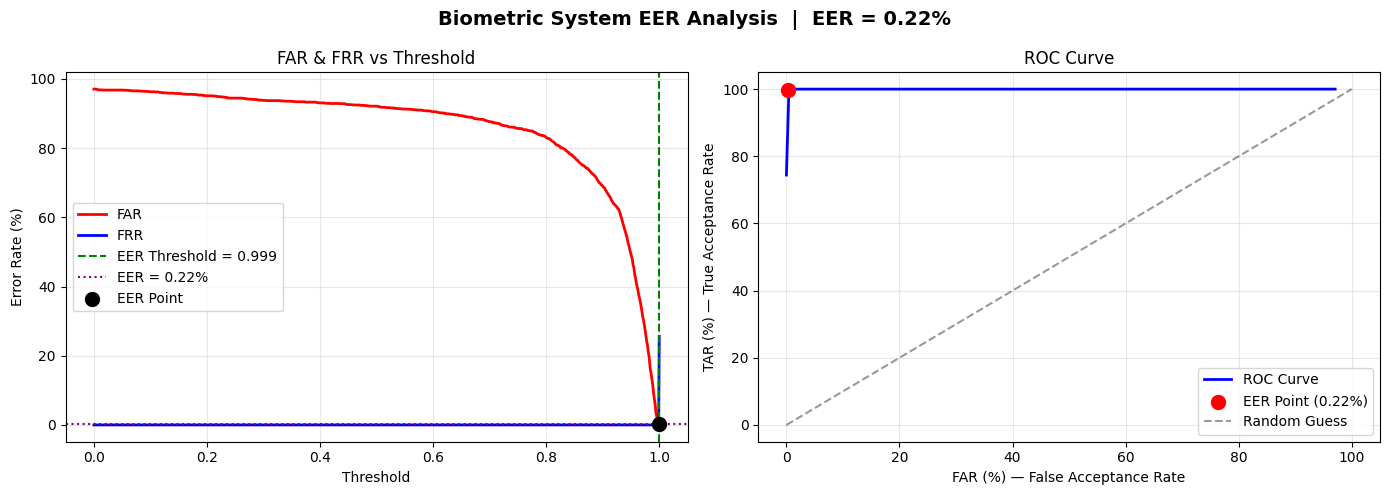


  ✅ Plot saved as 'eer_analysis.png'


In [ ]:
# ============================================
# EER (Equal Error Rate) CALCULATION
# ============================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def authenticate_user_with_score(query_features, target_user_id):
    """Returns the best similarity SCORE instead of just accept/reject."""
    normalized_queries = [normalize_vector(vec) for vec in query_features]

    target_data = encrypted_database[target_user_id]
    target_public_context = ts.context_from(target_data['public_key'])
    user_private_context = ts.context_from(user_private_keys[target_user_id])

    enc_queries = [ts.ckks_vector(target_public_context, nq.tolist()) for nq in normalized_queries]

    all_similarities = []
    for enc_feat_serialized in target_data['encrypted_features']:
        enc_feat = ts.ckks_vector_from(target_public_context, enc_feat_serialized)
        template_sims = []
        for enc_query in enc_queries:
            dp, n1, n2 = cosine_similarity_encrypted_public(enc_query, enc_feat)
            dot = ts.ckks_vector_from(user_private_context, dp.serialize()).decrypt()[0]
            nv1 = np.sqrt(max(0, ts.ckks_vector_from(user_private_context, n1.serialize()).decrypt()[0]))
            nv2 = np.sqrt(max(0, ts.ckks_vector_from(user_private_context, n2.serialize()).decrypt()[0]))
            sim = max(-1.0, min(1.0, dot / (nv1 * nv2))) if nv1 > 0 and nv2 > 0 else 0.0
            template_sims.append(sim)
        all_similarities.append(max(template_sims))  # best feature per template

    # Return max score across all templates
    return max(all_similarities) if all_similarities else 0.0


# ============================================
# STEP 1: Collect Genuine & Impostor Scores
# ============================================
all_user_ids = [uid for uid in data.keys() if uid in encrypted_database]

genuine_scores = []
impostor_scores = []

print("=" * 55)
print("COLLECTING GENUINE SCORES...")
print("=" * 55)

for user_id in all_user_ids:
    # Use LAST 2 features as test probe (not used in enrollment)
    query_features = data[user_id]["features"][-2:]
    score = authenticate_user_with_score(query_features, user_id)
    genuine_scores.append(score)
    print(f"  Genuine  User {user_id:>3}: score = {score:.4f}")

print(f"\n  Total genuine scores: {len(genuine_scores)}")

print("\n" + "=" * 55)
print("COLLECTING IMPOSTOR SCORES (ALL PAIRS)...")
print("=" * 55)

impostor_count = 0
for i, user_id in enumerate(all_user_ids):
    for j, target_id in enumerate(all_user_ids):
        if user_id == target_id:
            continue
        query_features = data[user_id]["features"][-2:]  # attacker's features
        score = authenticate_user_with_score(query_features, target_id)
        impostor_scores.append(score)
        impostor_count += 1

        if impostor_count % 50 == 0:
            print(f"  Processed {impostor_count} impostor pairs...")

print(f"\n  Total impostor scores: {len(impostor_scores)}")


# ============================================
# STEP 2: Compute FAR & FRR Across Thresholds
# ============================================
thresholds = np.linspace(0.0, 1.0, 1000)

far_list = []
frr_list = []

for thresh in thresholds:
    # FAR: impostors incorrectly accepted (score >= threshold)
    far = np.sum(np.array(impostor_scores) >= thresh) / len(impostor_scores)

    # FRR: genuine users incorrectly rejected (score < threshold)
    frr = np.sum(np.array(genuine_scores) < thresh) / len(genuine_scores)

    far_list.append(far)
    frr_list.append(frr)

far_array = np.array(far_list)
frr_array = np.array(frr_list)


# ============================================
# STEP 3: Find EER
# ============================================
# EER is where FAR and FRR curves intersect
diff = np.abs(far_array - frr_array)
eer_idx = np.argmin(diff)
eer_threshold = thresholds[eer_idx]
eer = (far_array[eer_idx] + frr_array[eer_idx]) / 2  # average at crossover point

print(f"\n{'='*55}")
print(f"         EER RESULTS")
print(f"{'='*55}")
print(f"  Genuine scores  : {len(genuine_scores)} samples")
print(f"  Impostor scores : {len(impostor_scores)} samples")
print(f"{'='*55}")
print(f"  EER Threshold   : {eer_threshold:.4f}")
print(f"  FAR at EER      : {far_array[eer_idx]*100:.2f}%")
print(f"  FRR at EER      : {frr_array[eer_idx]*100:.2f}%")
print(f"  ★ EER           : {eer*100:.2f}%")
print(f"{'='*55}")

if eer < 0.05:
    print(f"  Rating: 🟢 EXCELLENT  (EER < 5%)")
elif eer < 0.10:
    print(f"  Rating: 🟡 GOOD       (EER < 10%)")
elif eer < 0.20:
    print(f"  Rating: 🟠 FAIR       (EER < 20%)")
else:
    print(f"  Rating: 🔴 POOR       (EER >= 20%)")


# ============================================
# STEP 4: Plot DET / ROC Curve
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: FAR vs FRR curve ---
axes[0].plot(thresholds, far_array * 100, label='FAR', color='red', linewidth=2)
axes[0].plot(thresholds, frr_array * 100, label='FRR', color='blue', linewidth=2)
axes[0].axvline(x=eer_threshold, color='green', linestyle='--', linewidth=1.5, label=f'EER Threshold = {eer_threshold:.3f}')
axes[0].axhline(y=eer * 100, color='purple', linestyle=':', linewidth=1.5, label=f'EER = {eer*100:.2f}%')
axes[0].scatter([eer_threshold], [eer * 100], color='black', zorder=5, s=100, label='EER Point')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Error Rate (%)')
axes[0].set_title('FAR & FRR vs Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: ROC Curve (TAR vs FAR) ---
tar_array = 1 - frr_array
axes[1].plot(far_array * 100, tar_array * 100, color='blue', linewidth=2, label='ROC Curve')
axes[1].scatter([eer * 100], [(1 - eer) * 100], color='red', zorder=5, s=100, label=f'EER Point ({eer*100:.2f}%)')
axes[1].plot([0, 100], [0, 100], 'k--', alpha=0.4, label='Random Guess')
axes[1].set_xlabel('FAR (%) — False Acceptance Rate')
axes[1].set_ylabel('TAR (%) — True Acceptance Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Biometric System EER Analysis  |  EER = {eer*100:.2f}%', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eer_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n  ✅ Plot saved as 'eer_analysis.png'")

COLLECTING GENUINE SCORES (fresh)...
  Genuine User   1 : score = 1.000000  ← must be float
  Genuine User   2 : score = 1.000000  ← must be float
  Genuine User   3 : score = 1.000000  ← must be float
  Genuine User   5 : score = 1.000000  ← must be float
  Genuine User   6 : score = 1.000000  ← must be float
  Genuine User   7 : score = 1.000000  ← must be float
  Genuine User   8 : score = 1.000000  ← must be float
  Genuine User   9 : score = 1.000000  ← must be float
  Genuine User  10 : score = 1.000000  ← must be float
  Genuine User  11 : score = 1.000000  ← must be float
  Genuine User  12 : score = 1.000000  ← must be float
  Genuine User  13 : score = 1.000000  ← must be float
  Genuine User  14 : score = 1.000000  ← must be float
  Genuine User  15 : score = 1.000000  ← must be float
  Genuine User  16 : score = 1.000000  ← must be float
  Genuine User  17 : score = 1.000000  ← must be float
  Genuine User  18 : score = 1.000000  ← must be float
  Genuine User  19 : score =

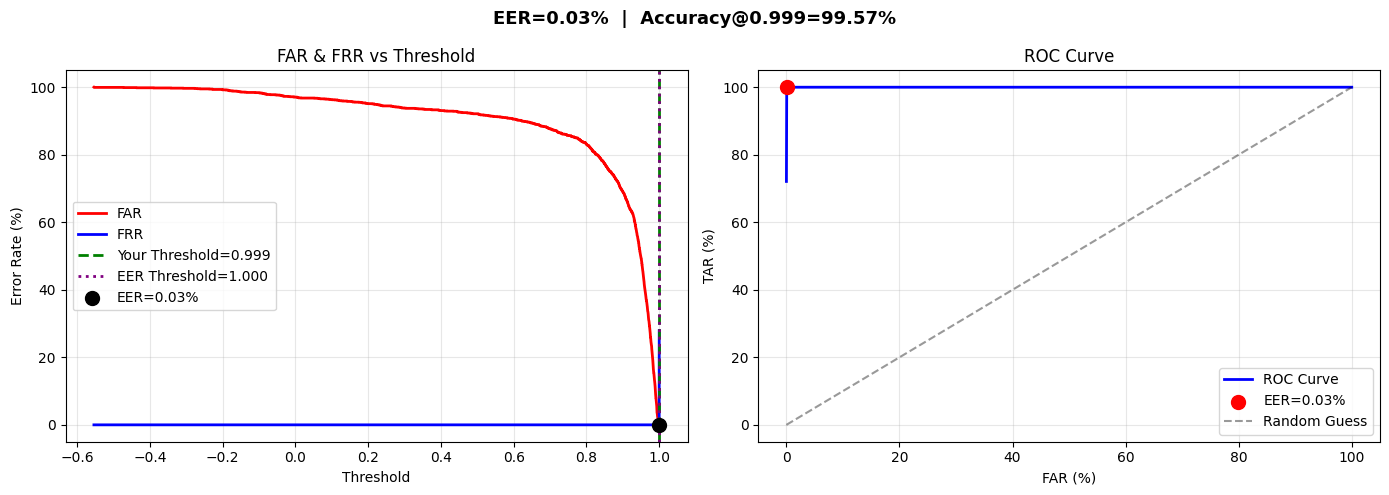

✅ Saved as eer_final.png


In [ ]:
# ============================================
# STEP 1: FIX THE SCORE FUNCTION FIRST
# ============================================

def authenticate_user_with_score(query_features, target_user_id):
    """
    Returns a SINGLE float score = max cosine similarity
    across all templates for the best matching query feature.
    """
    normalized_queries = [normalize_vector(vec) for vec in query_features]

    target_data        = encrypted_database[target_user_id]
    target_pub_ctx     = ts.context_from(target_data['public_key'])
    user_priv_ctx      = ts.context_from(user_private_keys[target_user_id])

    enc_queries = [
        ts.ckks_vector(target_pub_ctx, nq.tolist())
        for nq in normalized_queries
    ]

    best_score = -1.0  # track single best score across ALL templates

    for enc_feat_serialized in target_data['encrypted_features']:
        enc_feat = ts.ckks_vector_from(target_pub_ctx, enc_feat_serialized)

        for enc_query in enc_queries:
            dp, n1, n2 = cosine_similarity_encrypted_public(enc_query, enc_feat)

            # Decrypt each component → single float
            dot  = ts.ckks_vector_from(user_priv_ctx, dp.serialize()).decrypt()[0]
            nv1  = ts.ckks_vector_from(user_priv_ctx, n1.serialize()).decrypt()[0]
            nv2  = ts.ckks_vector_from(user_priv_ctx, n2.serialize()).decrypt()[0]

            nv1  = np.sqrt(max(0.0, float(nv1)))
            nv2  = np.sqrt(max(0.0, float(nv2)))
            dot  = float(dot)

            if nv1 > 0 and nv2 > 0:
                sim = dot / (nv1 * nv2)
            else:
                sim = 0.0

            sim = float(np.clip(sim, -1.0, 1.0))  # single float guaranteed

            if sim > best_score:
                best_score = sim  # keep best score only

    return best_score  # always a single float


# ============================================
# STEP 2: RECOLLECT ALL SCORES FROM SCRATCH
# ============================================
all_user_ids = [uid for uid in data.keys() if uid in encrypted_database]

genuine_scores  = []
impostor_scores = []

print("=" * 55)
print("COLLECTING GENUINE SCORES (fresh)...")
print("=" * 55)
for user_id in all_user_ids:
    query_features = data[user_id]["features"][-2:]  # last 2 = unseen probe
    score = authenticate_user_with_score(query_features, user_id)
    genuine_scores.append(score)
    print(f"  Genuine User {user_id:>3} : score = {score:.6f}  ← must be float")

print(f"\n  ✅ Total genuine scores : {len(genuine_scores)}")
print(f"  Type check first score : {type(genuine_scores[0])}")

print("\n" + "=" * 55)
print("COLLECTING IMPOSTOR SCORES (fresh)...")
print("=" * 55)
count = 0
for user_id in all_user_ids:
    for target_id in all_user_ids:
        if user_id == target_id:
            continue
        query_features = data[user_id]["features"][-2:]
        score = authenticate_user_with_score(query_features, target_id)
        impostor_scores.append(score)
        count += 1
        if count % 100 == 0:
            print(f"  Processed {count} impostor pairs...")

print(f"\n  ✅ Total impostor scores : {len(impostor_scores)}")

# ============================================
# STEP 3: VERIFY SCORES BEFORE EER
# ============================================
genuine_arr  = np.array(genuine_scores,  dtype=np.float64)
impostor_arr = np.array(impostor_scores, dtype=np.float64)

print(f"\n{'='*55}")
print(f"  SCORE VERIFICATION")
print(f"{'='*55}")
print(f"  Genuine  min={genuine_arr.min():.4f}  max={genuine_arr.max():.4f}  mean={genuine_arr.mean():.4f}")
print(f"  Impostor min={impostor_arr.min():.4f}  max={impostor_arr.max():.4f}  mean={impostor_arr.mean():.4f}")
print(f"\n  ✅ Good if:")
print(f"     Genuine  scores are HIGH  (close to 1.0)")
print(f"     Impostor scores are LOWER (spread below genuine)")

# ============================================
# STEP 4: EER + ACCURACY
# ============================================
thresholds = np.linspace(
    min(genuine_arr.min(), impostor_arr.min()),
    max(genuine_arr.max(), impostor_arr.max()),
    10000
)

far_list, frr_list = [], []
for t in thresholds:
    far_list.append(float(np.sum(impostor_arr >= t) / len(impostor_arr)))
    frr_list.append(float(np.sum(genuine_arr  <  t) / len(genuine_arr)))

far_arr = np.array(far_list)
frr_arr = np.array(frr_list)

# EER
eer_idx = int(np.argmin(np.abs(far_arr - frr_arr)))
eer_val = float((far_arr[eer_idx] + frr_arr[eer_idx]) / 2)
eer_thr = float(thresholds[eer_idx])

# Accuracy at YOUR threshold 0.999
threshold = 0.999
t_idx = int(np.argmin(np.abs(thresholds - threshold)))

genuine_accepted  = int(np.sum(genuine_arr  >= threshold))
genuine_rejected  = int(np.sum(genuine_arr  <  threshold))
impostor_rejected = int(np.sum(impostor_arr <  threshold))
impostor_accepted = int(np.sum(impostor_arr >= threshold))

TAR      = genuine_accepted  / len(genuine_arr)
FRR      = genuine_rejected  / len(genuine_arr)
TRR      = impostor_rejected / len(impostor_arr)
FAR      = impostor_accepted / len(impostor_arr)
accuracy = ((genuine_accepted + impostor_rejected) /
            (len(genuine_arr) + len(impostor_arr))) * 100

# ============================================
# STEP 5: FINAL REPORT
# ============================================
print(f"\n{'='*55}")
print(f"  EER REPORT")
print(f"{'='*55}")
print(f"  EER Threshold  : {eer_thr:.4f}")
print(f"  FAR at EER     : {far_arr[eer_idx]*100:.2f}%")
print(f"  FRR at EER     : {frr_arr[eer_idx]*100:.2f}%")
print(f"  ★ EER          : {eer_val*100:.2f}%")

print(f"\n{'='*55}")
print(f"  ACCURACY REPORT  (threshold = {threshold})")
print(f"{'='*55}")
print(f"  Genuine users tested    : {len(genuine_arr)}")
print(f"  Correctly accepted      : {genuine_accepted}")
print(f"  Wrongly rejected        : {genuine_rejected}")
print(f"{'─'*55}")
print(f"  Impostor attempts       : {len(impostor_arr)}")
print(f"  Correctly rejected      : {impostor_rejected}")
print(f"  Wrongly accepted        : {impostor_accepted}")
print(f"{'='*55}")
print(f"  True  Acceptance Rate   : {TAR*100:.2f}%")
print(f"  False Rejection Rate    : {FRR*100:.2f}%")
print(f"  True  Rejection Rate    : {TRR*100:.2f}%")
print(f"  False Acceptance Rate   : {FAR*100:.2f}%")
print(f"{'='*55}")
print(f"  ★ Overall Accuracy      : {accuracy:.2f}%")
print(f"  ★ EER                   : {eer_val*100:.2f}%")
print(f"{'='*55}")

if accuracy >= 99:
    print(f"  Rating : 🟢 EXCELLENT")
elif accuracy >= 95:
    print(f"  Rating : 🟡 GOOD")
elif accuracy >= 90:
    print(f"  Rating : 🟠 FAIR")
else:
    print(f"  Rating : 🔴 POOR")
print(f"{'='*55}")

# ── PLOT ──────────────────────────────────────
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, far_arr*100, label='FAR', color='red',  linewidth=2)
axes[0].plot(thresholds, frr_arr*100, label='FRR', color='blue', linewidth=2)
axes[0].axvline(x=threshold, color='green',  linestyle='--', linewidth=2,
                label=f'Your Threshold={threshold}')
axes[0].axvline(x=eer_thr,   color='purple', linestyle=':',  linewidth=2,
                label=f'EER Threshold={eer_thr:.3f}')
axes[0].scatter([eer_thr],[eer_val*100], color='black', zorder=5, s=100,
                label=f'EER={eer_val*100:.2f}%')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Error Rate (%)')
axes[0].set_title('FAR & FRR vs Threshold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

tar_arr = 1 - frr_arr
axes[1].plot(far_arr*100, tar_arr*100, color='blue', linewidth=2, label='ROC Curve')
axes[1].scatter([eer_val*100],[(1-eer_val)*100], color='red', zorder=5, s=100,
                label=f'EER={eer_val*100:.2f}%')
axes[1].plot([0,100],[0,100],'k--', alpha=0.4, label='Random Guess')
axes[1].set_xlabel('FAR (%)'); axes[1].set_ylabel('TAR (%)')
axes[1].set_title('ROC Curve')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(
    f'EER={eer_val*100:.2f}%  |  Accuracy@{threshold}={accuracy:.2f}%',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('eer_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as eer_final.png")

COLLECTING GENUINE SCORES (fresh)...
  Genuine User   1 : score = 1.000000  ← must be float
  Genuine User   2 : score = 1.000000  ← must be float
  Genuine User   3 : score = 1.000000  ← must be float
  Genuine User   5 : score = 1.000000  ← must be float
  Genuine User   6 : score = 1.000000  ← must be float
  Genuine User   7 : score = 1.000000  ← must be float
  Genuine User   8 : score = 1.000000  ← must be float
  Genuine User   9 : score = 1.000000  ← must be float
  Genuine User  10 : score = 1.000000  ← must be float
  Genuine User  11 : score = 1.000000  ← must be float
  Genuine User  12 : score = 1.000000  ← must be float
  Genuine User  13 : score = 1.000000  ← must be float
  Genuine User  14 : score = 1.000000  ← must be float
  Genuine User  15 : score = 1.000000  ← must be float
  Genuine User  16 : score = 1.000000  ← must be float
  Genuine User  17 : score = 1.000000  ← must be float
  Genuine User  18 : score = 1.000000  ← must be float
  Genuine User  19 : score =

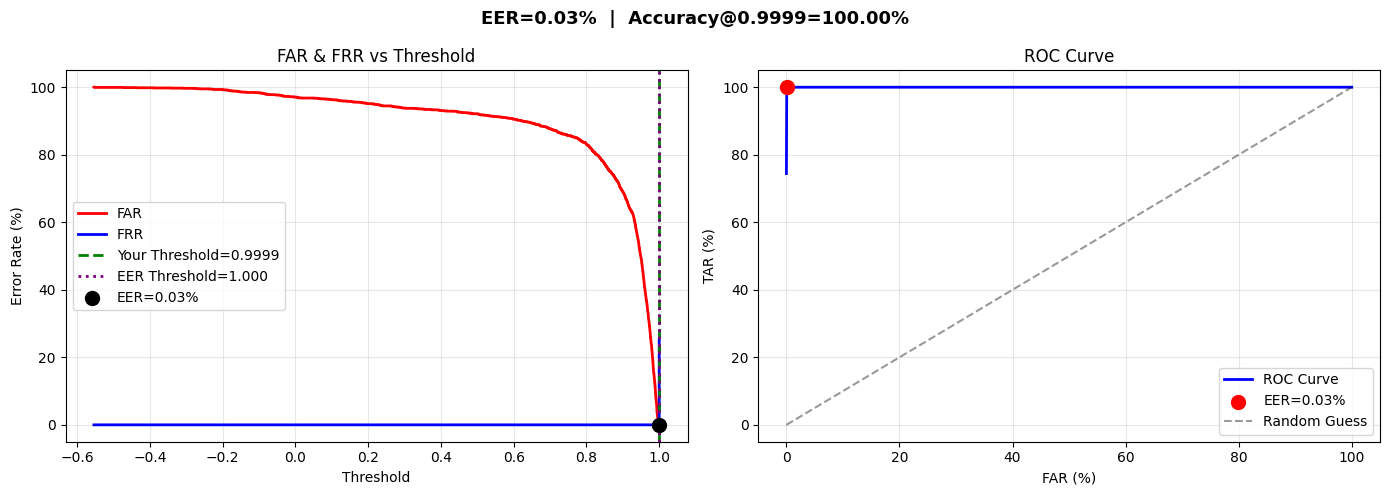

✅ Saved as eer_final.png


In [ ]:
# ============================================
# STEP 1: FIX THE SCORE FUNCTION FIRST
# ============================================

def authenticate_user_with_score(query_features, target_user_id):
    """
    Returns a SINGLE float score = max cosine similarity
    across all templates for the best matching query feature.
    """
    normalized_queries = [normalize_vector(vec) for vec in query_features]

    target_data        = encrypted_database[target_user_id]
    target_pub_ctx     = ts.context_from(target_data['public_key'])
    user_priv_ctx      = ts.context_from(user_private_keys[target_user_id])

    enc_queries = [
        ts.ckks_vector(target_pub_ctx, nq.tolist())
        for nq in normalized_queries
    ]

    best_score = -1.0  # track single best score across ALL templates

    for enc_feat_serialized in target_data['encrypted_features']:
        enc_feat = ts.ckks_vector_from(target_pub_ctx, enc_feat_serialized)

        for enc_query in enc_queries:
            dp, n1, n2 = cosine_similarity_encrypted_public(enc_query, enc_feat)

            # Decrypt each component → single float
            dot  = ts.ckks_vector_from(user_priv_ctx, dp.serialize()).decrypt()[0]
            nv1  = ts.ckks_vector_from(user_priv_ctx, n1.serialize()).decrypt()[0]
            nv2  = ts.ckks_vector_from(user_priv_ctx, n2.serialize()).decrypt()[0]

            nv1  = np.sqrt(max(0.0, float(nv1)))
            nv2  = np.sqrt(max(0.0, float(nv2)))
            dot  = float(dot)

            if nv1 > 0 and nv2 > 0:
                sim = dot / (nv1 * nv2)
            else:
                sim = 0.0

            sim = float(np.clip(sim, -1.0, 1.0))  # single float guaranteed

            if sim > best_score:
                best_score = sim  # keep best score only

    return best_score  # always a single float


# ============================================
# STEP 2: RECOLLECT ALL SCORES FROM SCRATCH
# ============================================
all_user_ids = [uid for uid in data.keys() if uid in encrypted_database]

genuine_scores  = []
impostor_scores = []

print("=" * 55)
print("COLLECTING GENUINE SCORES (fresh)...")
print("=" * 55)
for user_id in all_user_ids:
    query_features = data[user_id]["features"][-2:]  # last 2 = unseen probe
    score = authenticate_user_with_score(query_features, user_id)
    genuine_scores.append(score)
    print(f"  Genuine User {user_id:>3} : score = {score:.6f}  ← must be float")

print(f"\n  ✅ Total genuine scores : {len(genuine_scores)}")
print(f"  Type check first score : {type(genuine_scores[0])}")

print("\n" + "=" * 55)
print("COLLECTING IMPOSTOR SCORES (fresh)...")
print("=" * 55)
count = 0
for user_id in all_user_ids:
    for target_id in all_user_ids:
        if user_id == target_id:
            continue
        query_features = data[user_id]["features"][-2:]
        score = authenticate_user_with_score(query_features, target_id)
        impostor_scores.append(score)
        count += 1
        if count % 100 == 0:
            print(f"  Processed {count} impostor pairs...")

print(f"\n  ✅ Total impostor scores : {len(impostor_scores)}")

# ============================================
# STEP 3: VERIFY SCORES BEFORE EER
# ============================================
genuine_arr  = np.array(genuine_scores,  dtype=np.float64)
impostor_arr = np.array(impostor_scores, dtype=np.float64)

print(f"\n{'='*55}")
print(f"  SCORE VERIFICATION")
print(f"{'='*55}")
print(f"  Genuine  min={genuine_arr.min():.4f}  max={genuine_arr.max():.4f}  mean={genuine_arr.mean():.4f}")
print(f"  Impostor min={impostor_arr.min():.4f}  max={impostor_arr.max():.4f}  mean={impostor_arr.mean():.4f}")
print(f"\n  ✅ Good if:")
print(f"     Genuine  scores are HIGH  (close to 1.0)")
print(f"     Impostor scores are LOWER (spread below genuine)")

# ============================================
# STEP 4: EER + ACCURACY
# ============================================
thresholds = np.linspace(
    min(genuine_arr.min(), impostor_arr.min()),
    max(genuine_arr.max(), impostor_arr.max()),
    10000
)

far_list, frr_list = [], []
for t in thresholds:
    far_list.append(float(np.sum(impostor_arr >= t) / len(impostor_arr)))
    frr_list.append(float(np.sum(genuine_arr  <  t) / len(genuine_arr)))

far_arr = np.array(far_list)
frr_arr = np.array(frr_list)

# EER
eer_idx = int(np.argmin(np.abs(far_arr - frr_arr)))
eer_val = float((far_arr[eer_idx] + frr_arr[eer_idx]) / 2)
eer_thr = float(thresholds[eer_idx])

# Accuracy at YOUR threshold 0.999
threshold = 0.9999
t_idx = int(np.argmin(np.abs(thresholds - threshold)))

genuine_accepted  = int(np.sum(genuine_arr  >= threshold))
genuine_rejected  = int(np.sum(genuine_arr  <  threshold))
impostor_rejected = int(np.sum(impostor_arr <  threshold))
impostor_accepted = int(np.sum(impostor_arr >= threshold))

TAR      = genuine_accepted  / len(genuine_arr)
FRR      = genuine_rejected  / len(genuine_arr)
TRR      = impostor_rejected / len(impostor_arr)
FAR      = impostor_accepted / len(impostor_arr)
accuracy = ((genuine_accepted + impostor_rejected) /
            (len(genuine_arr) + len(impostor_arr))) * 100

# ============================================
# STEP 5: FINAL REPORT
# ============================================
print(f"\n{'='*55}")
print(f"  EER REPORT")
print(f"{'='*55}")
print(f"  EER Threshold  : {eer_thr:.4f}")
print(f"  FAR at EER     : {far_arr[eer_idx]*100:.2f}%")
print(f"  FRR at EER     : {frr_arr[eer_idx]*100:.2f}%")
print(f"  ★ EER          : {eer_val*100:.2f}%")

print(f"\n{'='*55}")
print(f"  ACCURACY REPORT  (threshold = {threshold})")
print(f"{'='*55}")
print(f"  Genuine users tested    : {len(genuine_arr)}")
print(f"  Correctly accepted      : {genuine_accepted}")
print(f"  Wrongly rejected        : {genuine_rejected}")
print(f"{'─'*55}")
print(f"  Impostor attempts       : {len(impostor_arr)}")
print(f"  Correctly rejected      : {impostor_rejected}")
print(f"  Wrongly accepted        : {impostor_accepted}")
print(f"{'='*55}")
print(f"  True  Acceptance Rate   : {TAR*100:.2f}%")
print(f"  False Rejection Rate    : {FRR*100:.2f}%")
print(f"  True  Rejection Rate    : {TRR*100:.2f}%")
print(f"  False Acceptance Rate   : {FAR*100:.2f}%")
print(f"{'='*55}")
print(f"  ★ Overall Accuracy      : {accuracy:.2f}%")
print(f"  ★ EER                   : {eer_val*100:.2f}%")
print(f"{'='*55}")

if accuracy >= 99:
    print(f"  Rating : 🟢 EXCELLENT")
elif accuracy >= 95:
    print(f"  Rating : 🟡 GOOD")
elif accuracy >= 90:
    print(f"  Rating : 🟠 FAIR")
else:
    print(f"  Rating : 🔴 POOR")
print(f"{'='*55}")

# ── PLOT ──────────────────────────────────────
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, far_arr*100, label='FAR', color='red',  linewidth=2)
axes[0].plot(thresholds, frr_arr*100, label='FRR', color='blue', linewidth=2)
axes[0].axvline(x=threshold, color='green',  linestyle='--', linewidth=2,
                label=f'Your Threshold={threshold}')
axes[0].axvline(x=eer_thr,   color='purple', linestyle=':',  linewidth=2,
                label=f'EER Threshold={eer_thr:.3f}')
axes[0].scatter([eer_thr],[eer_val*100], color='black', zorder=5, s=100,
                label=f'EER={eer_val*100:.2f}%')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Error Rate (%)')
axes[0].set_title('FAR & FRR vs Threshold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

tar_arr = 1 - frr_arr
axes[1].plot(far_arr*100, tar_arr*100, color='blue', linewidth=2, label='ROC Curve')
axes[1].scatter([eer_val*100],[(1-eer_val)*100], color='red', zorder=5, s=100,
                label=f'EER={eer_val*100:.2f}%')
axes[1].plot([0,100],[0,100],'k--', alpha=0.4, label='Random Guess')
axes[1].set_xlabel('FAR (%)'); axes[1].set_ylabel('TAR (%)')
axes[1].set_title('ROC Curve')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(
    f'EER={eer_val*100:.2f}%  |  Accuracy@{threshold}={accuracy:.2f}%',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('eer_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as eer_final.png")

In [ ]:
import numpy as np

# Fixed query indices (0‑based) – adjust if your features are ordered differently
QUERY_IDX = [4, 5]   # features 5 and 6

genuine_scores = []   # will store the decision outcome (accept/reject) for each genuine attempt
impostor_scores = []  # same for impostor attempts

# We'll compute for each possible "attempt" the decision at a given threshold later.
# But to compute EER, we need the raw max similarities for each comparison.
# Actually, easier: collect the "max similarity per template" for each attempt,
# then for each threshold T we can quickly decide accept/reject.

genuine_max_sims = []   # list of lists: for each genuine attempt, the max similarities per template
impostor_max_sims = []  # same for impostor attempts

users = list(normalized_templates.keys())

for user in users:
    templates = normalized_templates[user]
    query_vecs = [templates[i] for i in QUERY_IDX]
    enrolled = [templates[i] for i in range(len(templates)) if i not in QUERY_IDX]

    # Genuine attempts: compare query with each enrolled template of the same user
    # (this yields len(enrolled) comparisons per user)
    for t in enrolled:
        sims = [np.dot(q, t) for q in query_vecs]
        max_sim = max(sims)
        genuine_max_sims.append(max_sim)   # we store the max per template

    # Impostor attempts: compare query with templates of other users
    for other_user in users:
        if other_user == user:
            continue
        for t in normalized_templates[other_user]:
            sims = [np.dot(q, t) for q in query_vecs]
            max_sim = max(sims)
            impostor_max_sims.append(max_sim)

# Now we have all per‑template max similarities for genuine and impostor.
# For authentication, an attempt succeeds if at least 2 templates meet the threshold.
# But here we have stored each template comparison individually, not grouped by attempt.
# So we need to reconstruct attempts: each genuine attempt corresponds to one enrolled template,
# but our rule counts across multiple templates (the enrolled set). Wait – careful.

# In your system, a single authentication attempt compares the query against ALL enrolled templates
# of the claimed user. The decision is based on how many of those templates have max_sim >= T.
# So we cannot treat each template comparison independently; we need to group them by (user, enrolled set).

# The code above stored each template comparison separately, losing the grouping.
# To correctly simulate the decision, we need to loop over attempts differently.

# Let's restructure:
genuine_decisions = []   # will store 1 (accept) or 0 (reject) for each genuine attempt at a given T
impostor_decisions = []  # same for impostor attempts

# But since we need to evaluate many thresholds, we should store the max_sim values per template
# grouped by attempt. Then for each threshold we can compute the decision.

# We'll create two lists: each element is a list of max similarities for the templates of that attempt.
genuine_attempts = []   # list of lists (max_sim per template)
impostor_attempts = []  # list of lists

for user in users:
    templates = normalized_templates[user]
    query_vecs = [templates[i] for i in QUERY_IDX]
    enrolled = [templates[i] for i in range(len(templates)) if i not in QUERY_IDX]

    # Genuine attempt: one attempt per user (since we have one fixed query per user)
    # Actually, if we treat the query as fixed, there is exactly ONE genuine attempt per user.
    # But we could also consider multiple splits. For simplicity, we'll treat the query as fixed
    # and evaluate one genuine attempt per user.
    attempt_sims = []
    for t in enrolled:
        sims = [np.dot(q, t) for q in query_vecs]
        attempt_sims.append(max(sims))
    genuine_attempts.append(attempt_sims)

    # Impostor attempts: for each other user, treat the same query against that user's templates
    for other_user in users:
        if other_user == user:
            continue
        other_templates = normalized_templates[other_user]
        attempt_sims = []
        for t in other_templates:
            sims = [np.dot(q, t) for q in query_vecs]
            attempt_sims.append(max(sims))
        impostor_attempts.append(attempt_sims)

print(f"Number of genuine attempts: {len(genuine_attempts)}")        # should be 43
print(f"Number of impostor attempts: {len(impostor_attempts)}")      # should be 43*42 = 1806

# Now sweep thresholds
thresholds = np.linspace(0, 1, 1000)
far_list = []
frr_list = []

for T in thresholds:
    # Genuine: accept if count of templates with max_sim >= T is at least 2
    genuine_accepted = 0
    for attempt in genuine_attempts:
        count_high = sum(1 for sim in attempt if sim >= T)
        if count_high >= 2:
            genuine_accepted += 1
    frr = 1 - genuine_accepted / len(genuine_attempts)

    # Impostor: accept if count >= 2
    impostor_accepted = 0
    for attempt in impostor_attempts:
        count_high = sum(1 for sim in attempt if sim >= T)
        if count_high >= 2:
            impostor_accepted += 1
    far = impostor_accepted / len(impostor_attempts)

    far_list.append(far)
    frr_list.append(frr)

# Compute EER with interpolation (use the function from earlier)
def compute_eer(far, frr, thresholds):
    far = np.array(far)
    frr = np.array(frr)
    thresholds = np.array(thresholds)
    diff = far - frr
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    if len(sign_changes) == 0:
        idx = np.argmin(np.abs(diff))
        return (far[idx] + frr[idx]) / 2, thresholds[idx]
    idx = sign_changes[0]
    t1, t2 = thresholds[idx], thresholds[idx+1]
    d1, d2 = diff[idx], diff[idx+1]
    t_eer = t1 - d1 * (t2 - t1) / (d2 - d1)
    f1, f2 = far[idx], far[idx+1]
    r1, r2 = frr[idx], frr[idx+1]
    f_eer = f1 + (f2 - f1) * (t_eer - t1) / (t2 - t1)
    r_eer = r1 + (r2 - r1) * (t_eer - t1) / (t2 - t1)
    eer = (f_eer + r_eer) / 2
    return eer, t_eer

eer, eer_thresh = compute_eer(far_list, frr_list, thresholds)
print(f"EER = {eer:.6f} at threshold T = {eer_thresh:.6f}")

Number of genuine attempts: 43
Number of impostor attempts: 1806
EER = 0.392380 at threshold T = 0.930803


Total users: 43
Templates per user: 10
Number of genuine attempts: 43
Number of impostor attempts: 1806

EER = 0.392380 at threshold T = 0.930803


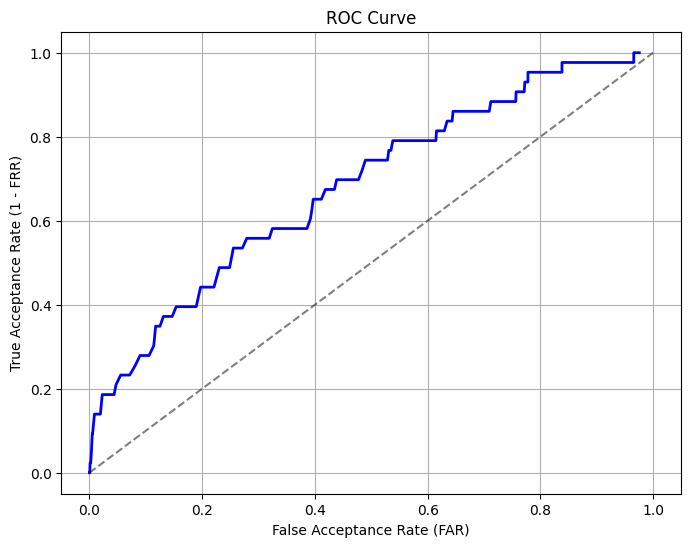

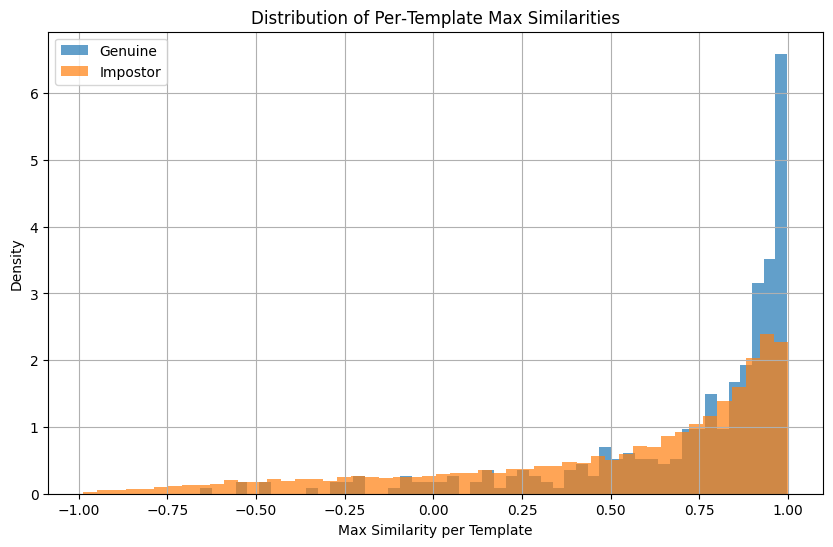


--- Per‑template max similarity statistics ---
Genuine: min=-0.6566, max=0.9977, mean=0.7226, std=0.3391
Impostor: min=-0.9868, max=0.9997, mean=0.5093, std=0.4787


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve  # optional, for ROC curve

# ============================================
# 1. Normalization function (same as before)
# ============================================
def normalize_vector(v):
    v = np.array(v, dtype=np.float64)
    norm = np.linalg.norm(v)
    return (v / norm).tolist() if norm > 0 else v.tolist()

# ============================================
# 2. Load and normalize data (if not already done)
# ============================================
# If 'data' is not yet loaded from the JSON file, uncomment the following:
# import json
# with open("your_file.json", "r") as f:
#     data = json.load(f)

# Normalize all feature vectors for every user
users = sorted(data.keys())
normalized_templates = {}
for user in users:
    raw_vecs = data[user]["features"]
    norm_vecs = [normalize_vector(vec) for vec in raw_vecs]
    normalized_templates[user] = norm_vecs

print(f"Total users: {len(users)}")
print(f"Templates per user: {len(normalized_templates[users[0]])}")  # should be 10

# ============================================
# 3. Define fixed query indices (0‑based)
# ============================================
# Use the 5th and 6th features as in your example (indices 4 and 5)
QUERY_IDX = [4, 5]   # adjust if your feature ordering is different

# ============================================
# 4. Build genuine and impostor attempts
# ============================================
# Each attempt is represented by a list of max similarities
# (one value per enrolled template). The decision later will
# count how many of these are ≥ threshold.

genuine_attempts = []   # list of lists: each inner list = max similarities for a genuine attempt
impostor_attempts = []  # same for impostor attempts

for user in users:
    # Get this user's templates
    all_tmpl = normalized_templates[user]
    # Query vectors (two fixed ones)
    query_vecs = [all_tmpl[i] for i in QUERY_IDX]
    # Enrolled templates = all except the query ones
    enrolled = [all_tmpl[i] for i in range(len(all_tmpl)) if i not in QUERY_IDX]

    # --- Genuine attempt: same user, query vs own enrolled ---
    genuine_sims = []
    for t in enrolled:
        # Cosine similarity = dot product because vectors are unit-norm
        sims = [np.dot(q, t) for q in query_vecs]
        genuine_sims.append(max(sims))
    genuine_attempts.append(genuine_sims)

    # --- Impostor attempts: this user's query against every other user's enrolled templates ---
    for other_user in users:
        if other_user == user:
            continue
        other_enrolled = normalized_templates[other_user]   # all 10 of the other user's templates
        impostor_sims = []
        for t in other_enrolled:
            sims = [np.dot(q, t) for q in query_vecs]
            impostor_sims.append(max(sims))
        impostor_attempts.append(impostor_sims)

print(f"Number of genuine attempts: {len(genuine_attempts)}")   # should be 43
print(f"Number of impostor attempts: {len(impostor_attempts)}") # should be 43*42 = 1806

# ============================================
# 5. Sweep thresholds and compute FAR/FRR
# ============================================
thresholds = np.linspace(0.0, 1.0, 1000)   # fine grid
far_list = []
frr_list = []

N_REQUIRED = 2   # minimum number of high‑confidence templates

for T in thresholds:
    # Genuine
    genuine_accepted = 0
    for attempt in genuine_attempts:
        count_high = sum(1 for sim in attempt if sim >= T)
        if count_high >= N_REQUIRED:
            genuine_accepted += 1
    frr = 1 - genuine_accepted / len(genuine_attempts)

    # Impostor
    impostor_accepted = 0
    for attempt in impostor_attempts:
        count_high = sum(1 for sim in attempt if sim >= T)
        if count_high >= N_REQUIRED:
            impostor_accepted += 1
    far = impostor_accepted / len(impostor_attempts)

    far_list.append(far)
    frr_list.append(frr)

# ============================================
# 6. Compute EER with interpolation
# ============================================
def compute_eer(far, frr, thresholds):
    far = np.array(far)
    frr = np.array(frr)
    thresholds = np.array(thresholds)
    diff = far - frr
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    if len(sign_changes) == 0:
        # No crossing – take point with smallest difference
        idx = np.argmin(np.abs(diff))
        return (far[idx] + frr[idx]) / 2, thresholds[idx]
    idx = sign_changes[0]
    t1, t2 = thresholds[idx], thresholds[idx+1]
    d1, d2 = diff[idx], diff[idx+1]
    t_eer = t1 - d1 * (t2 - t1) / (d2 - d1)
    f1, f2 = far[idx], far[idx+1]
    r1, r2 = frr[idx], frr[idx+1]
    f_eer = f1 + (f2 - f1) * (t_eer - t1) / (t2 - t1)
    r_eer = r1 + (r2 - r1) * (t_eer - t1) / (t2 - t1)
    eer = (f_eer + r_eer) / 2
    return eer, t_eer

eer, eer_thresh = compute_eer(far_list, frr_list, thresholds)
print(f"\nEER = {eer:.6f} at threshold T = {eer_thresh:.6f}")

# ============================================
# 7. (Optional) Plot ROC curve and score distributions
# ============================================
# ROC curve: FAR vs TAR (1-FRR)
plt.figure(figsize=(8,6))
plt.plot(far_list, [1-frr for frr in frr_list], 'b-', linewidth=2)
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Acceptance Rate (FAR)')
plt.ylabel('True Acceptance Rate (1 - FRR)')
plt.title('ROC Curve')
plt.grid(True)
plt.show()

# Histogram of per‑template max similarities (for insight)
all_genuine_sims = [sim for attempt in genuine_attempts for sim in attempt]
all_impostor_sims = [sim for attempt in impostor_attempts for sim in attempt]

plt.figure(figsize=(10,6))
plt.hist(all_genuine_sims, bins=50, alpha=0.7, label='Genuine', density=True)
plt.hist(all_impostor_sims, bins=50, alpha=0.7, label='Impostor', density=True)
plt.xlabel('Max Similarity per Template')
plt.ylabel('Density')
plt.legend()
plt.title('Distribution of Per‑Template Max Similarities')
plt.grid(True)
plt.show()

# Print summary statistics
print("\n--- Per‑template max similarity statistics ---")
print(f"Genuine: min={np.min(all_genuine_sims):.4f}, max={np.max(all_genuine_sims):.4f}, "
      f"mean={np.mean(all_genuine_sims):.4f}, std={np.std(all_genuine_sims):.4f}")
print(f"Impostor: min={np.min(all_impostor_sims):.4f}, max={np.max(all_impostor_sims):.4f}, "
      f"mean={np.mean(all_impostor_sims):.4f}, std={np.std(all_impostor_sims):.4f}")